In [95]:
import warnings
warnings.filterwarnings('ignore')

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import statsmodels.api as sm
import pymc as pm
from sklearn.model_selection import train_test_split

In [97]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,ics,pres_approval_avg_x_incpres,ics_x_incpres,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-15.715056
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-16.880853
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-17.206974
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-31.882701
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-18.025364


In [98]:
data.columns.values

array(['Unnamed: 0', 'year', 'state', 'state_po', 'special', 'district',
       'dem', 'rep', 'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc',
       'rep_inc', 'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'prev_lean', 'prev2_lean',
       'generic_ballot_avg', 'pres_approval_avg', 'incumbent_pres', 'ics',
       'pres_approval_avg_x_incpres', 'ics_x_incpres', 'no_dem_cand_flag',
       'no_rep_cand_flag', 'dem_inc_any', 'rep_inc_any', 'dem_inc_dummy',
       'rep_inc_dummy', 'pvi'], dtype=object)

In [99]:
data['rep_tot_funds'].isna().any()

np.False_

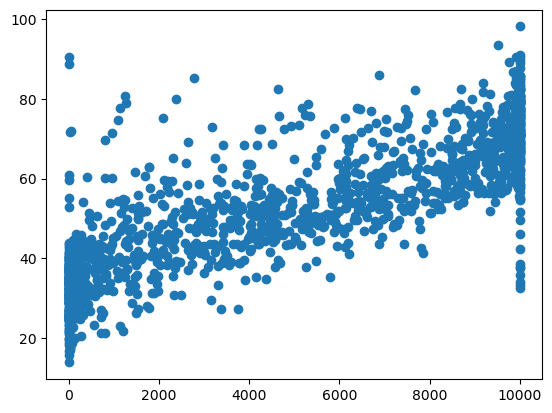

In [100]:
plt.scatter(data['dem_funds_2p_pct']**2, data['dem_pct_2p'])

In [101]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2

## Preliminary Model Check (Frequentist OLS)

In [111]:
y = data['dem_pct_2p']
X = data[['prev_lean', 'prev2_lean', 'generic_ballot_avg', 'pres_approval_avg_x_incpres', 'ics_x_incpres',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [112]:
X.corr()

,prev_lean,prev2_lean,generic_ballot_avg,pres_approval_avg_x_incpres,ics_x_incpres,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd
prev_lean,1.000000,0.978240,0.057372,-0.059119,0.060909,0.719866,-0.689081,0.787186
prev2_lean,0.978240,1.000000,0.057328,-0.056188,0.059092,0.721837,-0.684993,0.781953
generic_ballot_avg,0.057372,0.057328,1.000000,-0.945202,0.970366,0.013985,-0.046466,-0.036624
pres_approval_avg_x_incpres,-0.059119,-0.056188,-0.945202,1.000000,-0.993836,-0.008942,0.029399,0.017660
ics_x_incpres,0.060909,0.059092,0.970366,-0.993836,1.000000,0.016381,-0.038721,-0.024644
dem_inc_dummy,0.719866,0.721837,0.013985,-0.008942,0.016381,1.000000,-0.726200,0.695967
rep_inc_dummy,-0.689081,-0.684993,-0.046466,0.029399,-0.038721,-0.726200,1.000000,-0.694456
dem_funds_2p_pct_sqrd,0.787186,0.781953,-0.036624,0.017660,-0.024644,0.695967,-0.694456,1.000000


In [113]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     5836.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:00:40   Log-Likelihood:                -2466.9
No. Observations:                1019   AIC:                             4952.
Df Residuals:                    1010   BIC:                             4996.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          49.2215      0.431    114.128      0.000      48.376      50.067
prev_lean                       0.6331      0.036     17.697      0.000       0.563       0.703
prev2_lean                      0.2594      0.035      7.447      0.000       0.191       0.328
generic_ballot_avg              1.0056      0.127      7.901      0.000       0.756       1.255
pres_approval_avg_x_incpres    -0.9524      0.097     -9.808      0.000      -1.143      -0.762
ics_x_incpres                  -0.2161      0.021    -10.492      0.000      -0.256      -0.176
dem_inc_dummy                   0.3243      0.345      0.939      0.348      -0.353       1.001
rep_inc_dummy                  -1.7901      0.326     -5.485      0.000      -2.430      -1.150
dem_funds_2p_pct_sqrd           0.0004   4.83e-05      8.509      0.000       0.000       0.001
==============================================================================
Omnibus:                      481.150   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11765.791
Skew:                           1.615   Prob(JB):                         0.00
Kurtosis:                      19.331   Cond. No.                     3.00e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large,  3e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [118]:
y_test_hat = reg.predict(sm.add_constant(X_test))
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(7.737011493742209), np.float64(2.0368840347614294))

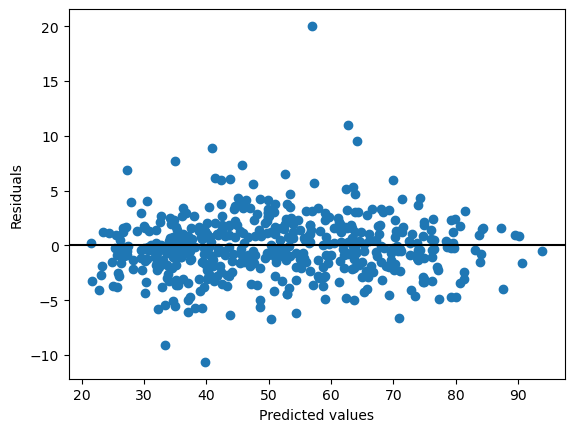

In [125]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

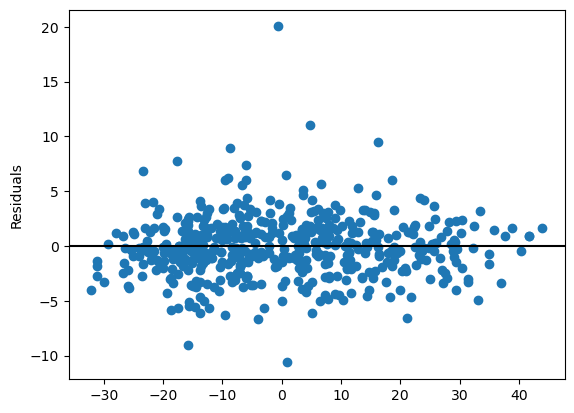

In [134]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

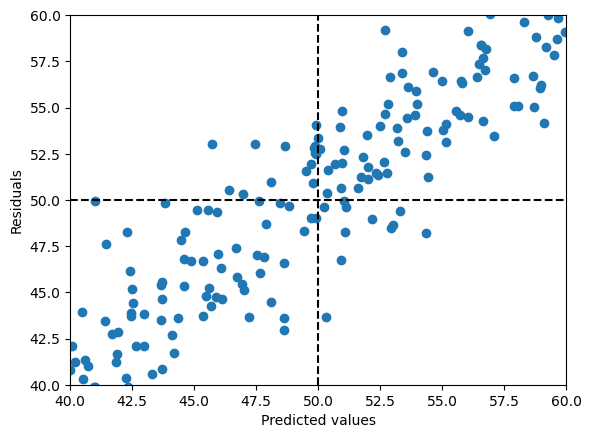

In [140]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');